In [2]:
import wfdb
import numpy as np
import pandas as pd
import os

In [3]:
# File paths (without extensions for wfdb)
data_path = '/Users/ajaybirheir/Documents/GitHub/ICPreg/Data/charis1'

# Read the record
record = wfdb.rdrecord(data_path)

# Check metadata
print("Signal names:", record.sig_name)
print("Number of samples:", record.sig_len)
print("Sampling frequency:", record.fs)

# Get signal data as a NumPy array
signals = record.p_signal  # shape: (samples, channels)
print("Signals shape:", signals.shape)

# Create a labeled table for the ABP, ECG, and ICP channels.
signals_df = pd.DataFrame(signals, columns=record.sig_name)
signals_abp_ecg_icp = signals_df[["ABP", "ECG", "ICP"]]



Signal names: ['ABP', 'ECG', 'ICP']
Number of samples: 12239851
Sampling frequency: 50
Signals shape: (12239851, 3)


In [4]:
print(signals_abp_ecg_icp.head())

        ABP       ECG        ICP
0 -0.011634  0.078763  21.079613
1 -0.011634  0.063800  20.573703
2 -0.046537  0.031078  20.468305
3  0.279222  0.014963  20.963676
4  0.162880  0.002138  20.984755


In [5]:
window_size = 15000
max_datapoint = 4320000

# Keep datapoints 1 through 4,320,000 (Python index 0 through 4,319,999).
window_data = signals_df.loc[: max_datapoint - 1, ["ICP", "ABP", "ECG"]].copy()
window_data["window_number"] = np.arange(len(window_data)) // window_size + 1

window_summary = (
    window_data.groupby("window_number")[["ICP", "ABP", "ECG"]]
    .agg(["mean", "max", "std"])
    .reset_index()
)

window_summary.columns = [
    "window_number",
    "icp_mean", "icp_max", "icp_std",
    "abp_mean", "abp_max", "abp_std",
    "ecg_mean", "ecg_max", "ecg_std",
]

window_summary.insert(1, "start_datapoint", (window_summary["window_number"] - 1) * window_size + 1)
window_summary.insert(2, "end_datapoint", window_summary["window_number"] * window_size)

window_summary.head()


   window_number  start_datapoint  end_datapoint   icp_mean    icp_max   icp_std   abp_mean     abp_max    abp_std  ecg_mean   ecg_max   ecg_std
0              1                1         15000  15.507324  28.660002  3.175714  81.384198  171.127079  14.454426  0.002419  1.191502  0.288351
1              2            15001         30000  17.777943  24.188907  1.780462  83.421651  170.661514  17.700970  0.001082  1.068811  0.271393
2              3            30001         45000  12.860375  18.915072  2.565671  84.031683  175.548409  17.096859  0.001221  1.278233  0.287677
3              4            45001         60000   7.269542  14.355870  2.344191  83.179784  180.317207  11.729725  0.001359  1.033908  0.274615
4              5            60001         75000   7.705490  14.929268  1.702141  84.247033  168.917133  14.069663  0.001449  1.112449  0.281935

In [ ]:
# Build the regression target: max ICP in the *next* 5-minute window.
# Each row's features come from window N; the label is the max ICP from window N+1.
window_summary["next_icp_max"] = window_summary["icp_max"].shift(-1)

# The last window has no "next" window, so drop it.
regression_data = window_summary.dropna(subset=["next_icp_max"]).reset_index(drop=True)

print(f"Rows available for regression: {len(regression_data)}")
regression_data.head()


In [10]:
# Build the same 5-min windowed feature table across ALL charis patients.
charis_dir = '/Users/ahmadmardini/Downloads/ICPreg/Data/charisdb'
window_size = 15000  # 5 min at 50 Hz
needed_signals = ["ICP", "ABP", "ECG"]

all_windows = []

for i in range(1, 14):  # charis1..charis13
    rec_path = os.path.join(charis_dir, f"charis{i}")
    try:
        rec = wfdb.rdrecord(rec_path)
    except Exception as e:
        print(f"charis{i}: failed to load ({e})")
        continue

    # Skip patients missing any of the three signals.
    if not all(s in rec.sig_name for s in needed_signals):
        print(f"charis{i}: missing signals, have {rec.sig_name}")
        continue

    df = pd.DataFrame(rec.p_signal, columns=rec.sig_name)[needed_signals].copy()

    # Trim to a whole number of windows.
    n_full = (len(df) // window_size) * window_size
    df = df.iloc[:n_full]

    df["window_number"] = np.arange(len(df)) // window_size + 1
    summary = (
        df.groupby("window_number")[needed_signals]
        .agg(["mean", "max", "std"])
        .reset_index()
    )
    summary.columns = [
        "window_number",
        "icp_mean", "icp_max", "icp_std",
        "abp_mean", "abp_max", "abp_std",
        "ecg_mean", "ecg_max", "ecg_std",
    ]
    summary.insert(0, "patient_id", f"charis{i}")
    all_windows.append(summary)
    print(f"charis{i}: {len(summary)} windows")

all_windows_df = pd.concat(all_windows, ignore_index=True)
print(f"\nTotal windows across all patients: {len(all_windows_df)}")
all_windows_df.head()


charis1: 815 windows
charis2: 4499 windows
charis3: 1139 windows
charis4: 479 windows
charis5: 2399 windows
charis6: 551 windows
charis7: 1612 windows
charis8: 1144 windows
charis9: 2051 windows
charis10: 1418 windows
charis11: 1155 windows
charis12: 1369 windows
charis13: 947 windows

Total windows across all patients: 19578


,patient_id,window_number,icp_mean,icp_max,icp_std,abp_mean,abp_max,abp_std,ecg_mean,ecg_max,ecg_std
0,charis1,1,20.171412,81.535945,5.001283,0.108651,0.954010,0.162840,0.046867,1.340290,0.201045
1,charis1,2,18.272176,27.941028,2.456290,0.121321,0.686422,0.159203,0.049253,1.357062,0.204704
2,charis1,3,18.100738,27.772391,2.436853,0.136023,0.686422,0.162487,0.051166,1.372847,0.206595
3,charis1,4,17.981330,38.017083,2.576762,0.146781,0.674787,0.164509,0.049485,1.372025,0.206655
4,charis1,5,17.840992,34.728663,2.421835,0.152721,0.802764,0.166773,0.049816,1.367092,0.207715


In [11]:
# Build the regression target PER patient so we never shift across patient boundaries.
all_windows_df["next_icp_max"] = (
    all_windows_df.groupby("patient_id")["icp_max"].shift(-1)
)

# Drop each patient's last window (no successor) and any rows with NaN features from std on single-row groups.
regression_data_all = all_windows_df.dropna().reset_index(drop=True)

print(f"Rows available for regression: {len(regression_data_all)}")
print(regression_data_all["patient_id"].value_counts().sort_index())
regression_data_all.head()


Rows available for regression: 19565
patient_id
charis1      814
charis10    1417
charis11    1154
charis12    1368
charis13     946
charis2     4498
charis3     1138
charis4      478
charis5     2398
charis6      550
charis7     1611
charis8     1143
charis9     2050
Name: count, dtype: int64


,patient_id,window_number,icp_mean,icp_max,icp_std,abp_mean,abp_max,abp_std,ecg_mean,ecg_max,ecg_std,next_icp_max
0,charis1,1,20.171412,81.535945,5.001283,0.108651,0.954010,0.162840,0.046867,1.340290,0.201045,27.941028
1,charis1,2,18.272176,27.941028,2.456290,0.121321,0.686422,0.159203,0.049253,1.357062,0.204704,27.772391
2,charis1,3,18.100738,27.772391,2.436853,0.136023,0.686422,0.162487,0.051166,1.372847,0.206595,38.017083
3,charis1,4,17.981330,38.017083,2.576762,0.146781,0.674787,0.164509,0.049485,1.372025,0.206655,34.728663
4,charis1,5,17.840992,34.728663,2.421835,0.152721,0.802764,0.166773,0.049816,1.367092,0.207715,26.338977


Summary statistics:


,icp_mean,icp_max,icp_std,abp_mean,abp_max,abp_std,ecg_mean,ecg_max,ecg_std,next_icp_max
count,19565.00,19565.00,19565.00,19565.00,19565.00,19565.00,19565.00,19565.00,19565.00,19565.00
mean,44.86,72.72,9.17,80.02,139.06,20.39,0.09,1.81,0.25,72.79
std,54.93,87.57,16.05,50.03,80.21,14.39,0.45,1.06,0.16,87.63
min,-100.47,-99.46,0.06,-336.41,0.05,0.10,-0.58,-0.09,0.00,-99.46
25%,13.29,20.37,1.20,73.14,119.56,16.76,0.02,1.09,0.16,20.37
50%,20.43,29.04,2.25,90.88,150.62,20.37,0.04,1.64,0.23,29.05
75%,89.58,100.88,4.99,104.13,173.63,23.89,0.06,2.02,0.27,100.90
max,367.67,410.54,175.34,294.72,408.79,308.73,3.95,5.45,3.07,410.54


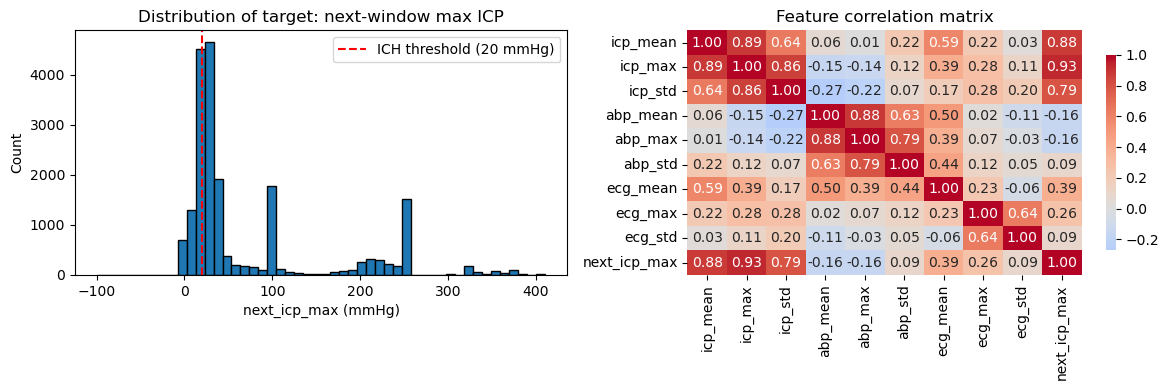


ICH rate (windows with max > 20 mmHg): 76.1%


In [12]:
# ---- Descriptive statistics ----
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = [
    "icp_mean", "icp_max", "icp_std",
    "abp_mean", "abp_max", "abp_std",
    "ecg_mean", "ecg_max", "ecg_std",
]
target_col = "next_icp_max"

print("Summary statistics:")
display(regression_data_all[feature_cols + [target_col]].describe().round(2))

# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(regression_data_all[target_col], bins=50, edgecolor="black")
axes[0].axvline(20, color="red", linestyle="--", label="ICH threshold (20 mmHg)")
axes[0].set_xlabel("next_icp_max (mmHg)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of target: next-window max ICP")
axes[0].legend()

# Correlation heatmap
corr = regression_data_all[feature_cols + [target_col]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"shrink": 0.8}, ax=axes[1])
axes[1].set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

print(f"\nICH rate (windows with max > 20 mmHg): "
      f"{(regression_data_all[target_col] > 20).mean():.1%}")


In [13]:
# ---- Model 1: Default linear regression (no tuning, all features) ----
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

X = regression_data_all[feature_cols].values
y = regression_data_all[target_col].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

baseline = LinearRegression().fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

r2_baseline = r2_score(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print("=== Model 1: Default Linear Regression ===")
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"R²:   {r2_baseline:.4f}")
print(f"RMSE: {rmse_baseline:.4f} mmHg")
print("\nCoefficients:")
for name, coef in zip(feature_cols, baseline.coef_):
    print(f"  {name:>10s}: {coef:+.4f}")
print(f"  intercept: {baseline.intercept_:+.4f}")


=== Model 1: Default Linear Regression ===
Train size: 15652 | Test size: 3913
R²:   0.8800
RMSE: 29.0853 mmHg

Coefficients:
    icp_mean: +0.6320
     icp_max: +0.4740
     icp_std: +0.6027
    abp_mean: -0.0798
     abp_max: -0.0340
     abp_std: +0.0225
    ecg_mean: -5.8319
     ecg_max: +3.8330
     ecg_std: -20.0204
  intercept: +13.8270


In [14]:
# ---- Model 2: Linear regression with feature selection ----
# Drop collinear features using VIF, then refit.
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(df):
    vif = pd.DataFrame({"feature": df.columns})
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif.sort_values("VIF", ascending=False).reset_index(drop=True)

X_train_df = pd.DataFrame(X_train, columns=feature_cols)
print("Initial VIF (values >10 indicate problematic multicollinearity):")
print(compute_vif(X_train_df))

# Iteratively drop the highest-VIF feature until all remaining VIFs are < 10.
selected = feature_cols.copy()
while True:
    vif_df = compute_vif(X_train_df[selected])
    worst = vif_df.iloc[0]
    if worst["VIF"] < 10 or len(selected) <= 1:
        break
    selected.remove(worst["feature"])
    print(f"  dropped {worst['feature']} (VIF={worst['VIF']:.1f})")

print(f"\nFinal selected features ({len(selected)}): {selected}")

# Fit using statsmodels for p-values.
X_train_sel = sm.add_constant(X_train_df[selected])
ols = sm.OLS(y_train, X_train_sel).fit()
print("\nOLS summary on selected features:")
print(ols.summary())

# Evaluate on test set.
X_test_sel = sm.add_constant(pd.DataFrame(X_test, columns=feature_cols)[selected])
y_pred_selected = ols.predict(X_test_sel)
r2_selected = r2_score(y_test, y_pred_selected)
rmse_selected = np.sqrt(mean_squared_error(y_test, y_pred_selected))

print(f"\n=== Model 2: Linear + feature selection ({len(selected)} features) ===")
print(f"R²:   {r2_selected:.4f}")
print(f"RMSE: {rmse_selected:.4f} mmHg")


Initial VIF (values >10 indicate problematic multicollinearity):
    feature        VIF
0   abp_max  36.573849
1   icp_max  26.542639
2  abp_mean  21.094938
3  icp_mean  14.957146
4   abp_std  10.972069
5   icp_std   7.513445
6   ecg_max   7.477816
7   ecg_std   6.111257
8  ecg_mean   2.167848
  dropped abp_max (VIF=36.6)
  dropped icp_max (VIF=25.8)

Final selected features (7): ['icp_mean', 'icp_std', 'abp_mean', 'abp_std', 'ecg_mean', 'ecg_max', 'ecg_std']

OLS summary on selected features:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.868
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                 1.473e+04
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:05:53   Log-Likelihood:                -76514.
No. Observations:          

In [15]:
# ---- Model 3: Ridge and Lasso with standardization + CV-picked alpha ----
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.pipeline import Pipeline

alphas = np.logspace(-3, 3, 50)

ridge_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas, cv=5)),
]).fit(X_train, y_train)

lasso_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("lasso", LassoCV(alphas=alphas, cv=5, max_iter=10000)),
]).fit(X_train, y_train)

y_pred_ridge = ridge_pipe.predict(X_test)
y_pred_lasso = lasso_pipe.predict(X_test)

r2_ridge  = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_lasso  = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("=== Model 3a: Ridge (alpha chosen by 5-fold CV) ===")
print(f"alpha = {ridge_pipe.named_steps['ridge'].alpha_:.4f}")
print(f"R²:   {r2_ridge:.4f}")
print(f"RMSE: {rmse_ridge:.4f} mmHg")
print("Coefficients (on standardized features):")
for name, coef in zip(feature_cols, ridge_pipe.named_steps["ridge"].coef_):
    print(f"  {name:>10s}: {coef:+.4f}")

print("\n=== Model 3b: Lasso (alpha chosen by 5-fold CV) ===")
print(f"alpha = {lasso_pipe.named_steps['lasso'].alpha_:.4f}")
print(f"R²:   {r2_lasso:.4f}")
print(f"RMSE: {rmse_lasso:.4f} mmHg")
print("Coefficients (on standardized features; 0 = dropped by Lasso):")
for name, coef in zip(feature_cols, lasso_pipe.named_steps["lasso"].coef_):
    print(f"  {name:>10s}: {coef:+.4f}")


=== Model 3a: Ridge (alpha chosen by 5-fold CV) ===
alpha = 33.9322
R²:   0.8800
RMSE: 29.0886 mmHg
Coefficients (on standardized features):
    icp_mean: +35.3581
     icp_max: +41.3614
     icp_std: +10.0334
    abp_mean: -4.0853
     abp_max: -2.7225
     abp_std: +0.2957
    ecg_mean: -2.6013
     ecg_max: +4.0596
     ecg_std: -3.1884

=== Model 3b: Lasso (alpha chosen by 5-fold CV) ===
alpha = 0.0010
R²:   0.8800
RMSE: 29.0852 mmHg
Coefficients (on standardized features; 0 = dropped by Lasso):
    icp_mean: +35.2414
     icp_max: +41.8651
     icp_std: +9.7199
    abp_mean: -4.0415
     abp_max: -2.7432
     abp_std: +0.3204
    ecg_mean: -2.7073
     ecg_max: +4.0587
     ecg_std: -3.1869


In [16]:
# ---- Comparison table across all models ----
comparison = pd.DataFrame([
    {"Model": "1. Default Linear",        "Features": len(feature_cols), "R² (test)": r2_baseline, "RMSE (test)": rmse_baseline},
    {"Model": "2. Linear + VIF selection","Features": len(selected),     "R² (test)": r2_selected, "RMSE (test)": rmse_selected},
    {"Model": "3a. Ridge (CV)",           "Features": len(feature_cols), "R² (test)": r2_ridge,    "RMSE (test)": rmse_ridge},
    {"Model": "3b. Lasso (CV)",           "Features": int((lasso_pipe.named_steps['lasso'].coef_ != 0).sum()), "R² (test)": r2_lasso, "RMSE (test)": rmse_lasso},
])
comparison = comparison.round(4)
print("=== Model comparison (held-out test set) ===")
display(comparison)

best_idx = comparison["R² (test)"].idxmax()
print(f"\nBest by R²: {comparison.loc[best_idx, 'Model']}")


=== Model comparison (held-out test set) ===


,Model,Features,R² (test),RMSE (test)
0,1. Default Linear,9,0.880,29.0853
1,2. Linear + VIF selection,7,0.865,30.8542
2,3a. Ridge (CV),9,0.880,29.0886
3,3b. Lasso (CV),9,0.880,29.0852



Best by R²: 1. Default Linear


In [17]:
# ---- Diagnostic: the R² above is misleading if a few outliers dominate the target ----
print("Target (next_icp_max) summary:")
print(regression_data_all["next_icp_max"].describe())

print("\nHow much of the variance comes from extreme values?")
q99 = regression_data_all["next_icp_max"].quantile(0.99)
print(f"99th percentile: {q99:.1f} mmHg")
print(f"Max observed:    {regression_data_all['next_icp_max'].max():.1f} mmHg")
print(f"Rows above 100 mmHg (physiologically impossible, likely sensor artifact): "
      f"{(regression_data_all['next_icp_max'] > 100).sum()}")

# Naive baseline: predict next_icp_max = current icp_max (persistence).
persistence_pred = regression_data_all["icp_max"].values
persistence_rmse = np.sqrt(mean_squared_error(
    regression_data_all["next_icp_max"], persistence_pred
))
persistence_r2 = r2_score(
    regression_data_all["next_icp_max"], persistence_pred
)
print(f"\nPersistence baseline (predict next = current):")
print(f"  R²:   {persistence_r2:.4f}")
print(f"  RMSE: {persistence_rmse:.4f} mmHg")
print("If your linear model barely beats this, the 'learning' is trivial copy-forward.")


Target (next_icp_max) summary:
count    19565.000000
mean        72.790404
std         87.629961
min        -99.461236
25%         20.372191
50%         29.053803
75%        100.895123
max        410.538987
Name: next_icp_max, dtype: float64

How much of the variance comes from extreme values?
99th percentile: 358.3 mmHg
Max observed:    410.5 mmHg
Rows above 100 mmHg (physiologically impossible, likely sensor artifact): 5172

Persistence baseline (predict next = current):
  R²:   0.8552
  RMSE: 33.3480 mmHg
If your linear model barely beats this, the 'learning' is trivial copy-forward.


In [18]:
# ---- Rebuild the dataset with physiologic filtering, then re-run all models ----
# Physiologic ranges (generous for ICU patients):
#   ICP: 0..80 mmHg  (normal 7-15; ICH >20; >60 is terminal)
#   ABP: 30..250 mmHg
#   ECG: -5..5 mV
PHYS_RANGES = {"ICP": (0, 80), "ABP": (30, 250), "ECG": (-5, 5)}

def mask_artifacts(df):
    out = df.copy()
    for col, (lo, hi) in PHYS_RANGES.items():
        out[col] = out[col].where((out[col] >= lo) & (out[col] <= hi))
    return out

all_windows_clean = []
for i in range(1, 14):
    rec_path = os.path.join(charis_dir, f"charis{i}")
    try:
        rec = wfdb.rdrecord(rec_path)
    except Exception:
        continue
    if not all(s in rec.sig_name for s in needed_signals):
        continue

    df = pd.DataFrame(rec.p_signal, columns=rec.sig_name)[needed_signals].copy()
    df = mask_artifacts(df)

    n_full = (len(df) // window_size) * window_size
    df = df.iloc[:n_full]
    df["window_number"] = np.arange(len(df)) // window_size + 1

    # Require each window to have >=90% valid samples in every signal.
    valid_frac = df.groupby("window_number")[needed_signals].apply(
        lambda g: g.notna().mean()
    )
    good_windows = valid_frac[(valid_frac >= 0.90).all(axis=1)].index
    df = df[df["window_number"].isin(good_windows)]
    if df.empty:
        continue

    summary = (
        df.groupby("window_number")[needed_signals]
        .agg(["mean", "max", "std"])
        .reset_index()
    )
    summary.columns = [
        "window_number",
        "icp_mean", "icp_max", "icp_std",
        "abp_mean", "abp_max", "abp_std",
        "ecg_mean", "ecg_max", "ecg_std",
    ]
    summary.insert(0, "patient_id", f"charis{i}")
    all_windows_clean.append(summary)
    print(f"charis{i}: {len(summary)} clean windows")

all_windows_df_clean = pd.concat(all_windows_clean, ignore_index=True)
all_windows_df_clean["next_icp_max"] = (
    all_windows_df_clean.groupby("patient_id")["icp_max"].shift(-1)
)
regression_data_clean = all_windows_df_clean.dropna().reset_index(drop=True)
print(f"\nClean rows for regression: {len(regression_data_clean)}")
print(regression_data_clean["next_icp_max"].describe().round(2))


charis1: 782 clean windows
charis2: 3783 clean windows
charis3: 589 clean windows
charis4: 236 clean windows
charis5: 1930 clean windows
charis6: 541 clean windows
charis7: 1316 clean windows
charis8: 303 clean windows
charis9: 625 clean windows
charis10: 279 clean windows
charis11: 555 clean windows
charis12: 704 clean windows
charis13: 799 clean windows

Clean rows for regression: 12429
count    12429.00
mean        27.56
std         14.98
min          0.72
25%         19.04
50%         24.63
75%         32.31
max         80.00
Name: next_icp_max, dtype: float64


In [19]:
# ---- Re-run all four models on the CLEAN dataset ----
Xc = regression_data_clean[feature_cols].values
yc = regression_data_clean[target_col].values

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.2, random_state=42)

# Model 1: default linear
m1 = LinearRegression().fit(Xc_tr, yc_tr)
r2_1 = r2_score(yc_te, m1.predict(Xc_te))
rmse_1 = np.sqrt(mean_squared_error(yc_te, m1.predict(Xc_te)))

# Model 2: VIF-based feature selection
Xc_tr_df = pd.DataFrame(Xc_tr, columns=feature_cols)
sel = feature_cols.copy()
while True:
    vif_df = compute_vif(Xc_tr_df[sel])
    worst = vif_df.iloc[0]
    if worst["VIF"] < 10 or len(sel) <= 1:
        break
    sel.remove(worst["feature"])
m2 = LinearRegression().fit(Xc_tr_df[sel].values, yc_tr)
Xc_te_sel = pd.DataFrame(Xc_te, columns=feature_cols)[sel].values
r2_2 = r2_score(yc_te, m2.predict(Xc_te_sel))
rmse_2 = np.sqrt(mean_squared_error(yc_te, m2.predict(Xc_te_sel)))

# Model 3a: Ridge
m3a = Pipeline([("s", StandardScaler()), ("r", RidgeCV(alphas=alphas, cv=5))]).fit(Xc_tr, yc_tr)
r2_3a = r2_score(yc_te, m3a.predict(Xc_te))
rmse_3a = np.sqrt(mean_squared_error(yc_te, m3a.predict(Xc_te)))

# Model 3b: Lasso
m3b = Pipeline([("s", StandardScaler()), ("l", LassoCV(alphas=alphas, cv=5, max_iter=10000))]).fit(Xc_tr, yc_tr)
r2_3b = r2_score(yc_te, m3b.predict(Xc_te))
rmse_3b = np.sqrt(mean_squared_error(yc_te, m3b.predict(Xc_te)))

# Persistence baseline on CLEAN data
persist_r2 = r2_score(yc, regression_data_clean["icp_max"])
persist_rmse = np.sqrt(mean_squared_error(yc, regression_data_clean["icp_max"]))

comparison_clean = pd.DataFrame([
    {"Model": "Persistence (trivial)",     "Features": 1,              "R² (test)": persist_r2, "RMSE (test)": persist_rmse},
    {"Model": "1. Default Linear",          "Features": len(feature_cols), "R² (test)": r2_1,  "RMSE (test)": rmse_1},
    {"Model": f"2. Linear + VIF ({len(sel)} feats)","Features": len(sel),"R² (test)": r2_2,  "RMSE (test)": rmse_2},
    {"Model": "3a. Ridge (CV)",             "Features": len(feature_cols), "R² (test)": r2_3a, "RMSE (test)": rmse_3a},
    {"Model": "3b. Lasso (CV)",             "Features": int((m3b.named_steps['l'].coef_ != 0).sum()), "R² (test)": r2_3b, "RMSE (test)": rmse_3b},
]).round(4)

print("=== Comparison on CLEAN data ===")
display(comparison_clean)
print(f"\nTarget std on clean data: {yc.std():.2f} mmHg "
      f"(RMSE should be well below this to be useful)")


=== Comparison on CLEAN data ===


,Model,Features,R² (test),RMSE (test)
0,Persistence (trivial),1,0.2106,13.3086
1,1. Default Linear,9,0.4310,11.0047
2,2. Linear + VIF (4 feats),4,0.3935,11.3608
3,3a. Ridge (CV),9,0.4311,11.0039
4,3b. Lasso (CV),9,0.4310,11.0041



Target std on clean data: 14.98 mmHg (RMSE should be well below this to be useful)


In [20]:
# ---- Enrich the feature set: add lag features from windows N-1 and N-2 ----
# Per patient, so lags never cross patient boundaries.
lagged_parts = [all_windows_df_clean[["patient_id", "window_number"] + feature_cols].copy()]
for lag in [1, 2]:
    lag_df = all_windows_df_clean.groupby("patient_id")[feature_cols].shift(lag)
    lag_df.columns = [f"{c}_lag{lag}" for c in feature_cols]
    lagged_parts.append(lag_df)

enriched = pd.concat(lagged_parts, axis=1)
enriched["next_icp_max"] = (
    all_windows_df_clean.groupby("patient_id")["icp_max"].shift(-1)
)
enriched = enriched.dropna().reset_index(drop=True)

lag_feature_cols = (
    feature_cols
    + [f"{c}_lag1" for c in feature_cols]
    + [f"{c}_lag2" for c in feature_cols]
)
print(f"Rows after lagging: {len(enriched)}")
print(f"Total features (current + lag1 + lag2): {len(lag_feature_cols)}")


Rows after lagging: 12403
Total features (current + lag1 + lag2): 27


In [21]:
# ---- Fit improved models on the enriched dataset ----
from sklearn.preprocessing import PolynomialFeatures

ye = enriched["next_icp_max"].values

# Split once with the enriched indices so every improved model uses the same test rows.
idx = np.arange(len(enriched))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42)

# --- Model 4: Linear with lag features (27 features) ---
Xlag = enriched[lag_feature_cols].values
m4 = LinearRegression().fit(Xlag[idx_tr], ye[idx_tr])
r2_4 = r2_score(ye[idx_te], m4.predict(Xlag[idx_te]))
rmse_4 = np.sqrt(mean_squared_error(ye[idx_te], m4.predict(Xlag[idx_te])))

# --- Model 5: Ridge with polynomial (degree 2) on the 9 current-window features ---
Xcur = enriched[feature_cols].values
m5 = Pipeline([
    ("poly",  PolynomialFeatures(degree=2, include_bias=False)),
    ("scale", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas, cv=5)),
]).fit(Xcur[idx_tr], ye[idx_tr])
r2_5 = r2_score(ye[idx_te], m5.predict(Xcur[idx_te]))
rmse_5 = np.sqrt(mean_squared_error(ye[idx_te], m5.predict(Xcur[idx_te])))

# --- Model 6: Ridge with lag features + pairwise interactions ---
m6 = Pipeline([
    ("poly",  PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ("scale", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas, cv=5)),
]).fit(Xlag[idx_tr], ye[idx_tr])
r2_6 = r2_score(ye[idx_te], m6.predict(Xlag[idx_te]))
rmse_6 = np.sqrt(mean_squared_error(ye[idx_te], m6.predict(Xlag[idx_te])))

# --- Refit baseline and Ridge on the SAME split for a fair comparison ---
m1b = LinearRegression().fit(Xcur[idx_tr], ye[idx_tr])
r2_1b = r2_score(ye[idx_te], m1b.predict(Xcur[idx_te]))
rmse_1b = np.sqrt(mean_squared_error(ye[idx_te], m1b.predict(Xcur[idx_te])))

persist_r2_te = r2_score(ye[idx_te], enriched["icp_max"].values[idx_te])
persist_rmse_te = np.sqrt(
    mean_squared_error(ye[idx_te], enriched["icp_max"].values[idx_te])
)

comparison_improved = pd.DataFrame([
    {"Model": "Persistence (trivial)",        "Features": 1,                    "R² (test)": persist_r2_te,  "RMSE (test)": persist_rmse_te},
    {"Model": "1. Default Linear (current)",  "Features": len(feature_cols),    "R² (test)": r2_1b,          "RMSE (test)": rmse_1b},
    {"Model": "4. Linear + lags (N-1, N-2)",  "Features": len(lag_feature_cols),"R² (test)": r2_4,           "RMSE (test)": rmse_4},
    {"Model": "5. Ridge + Poly (deg 2)",      "Features": m5.named_steps['poly'].n_output_features_, "R² (test)": r2_5, "RMSE (test)": rmse_5},
    {"Model": "6. Ridge + lags + interactions","Features": m6.named_steps['poly'].n_output_features_,"R² (test)": r2_6, "RMSE (test)": rmse_6},
]).round(4)

print("=== Improved models (same test split across all rows) ===")
display(comparison_improved)
print(f"\nTarget std: {ye.std():.2f} mmHg")


=== Improved models (same test split across all rows) ===


,Model,Features,R² (test),RMSE (test)
0,Persistence (trivial),1,0.2596,12.6419
1,1. Default Linear (current),9,0.4606,10.7904
2,"4. Linear + lags (N-1, N-2)",27,0.4670,10.7258
3,5. Ridge + Poly (deg 2),54,0.4722,10.6739
4,6. Ridge + lags + interactions,378,0.4675,10.7207



Target std: 14.97 mmHg


In [ ]:
# ---- Add patient fixed effects (one-hot encode patient_id) ----
# Intuition: each patient has a different baseline ICP. A global model can't
# reconcile them; patient dummies give every patient their own intercept.
patient_dummies = pd.get_dummies(enriched["patient_id"], prefix="pat", drop_first=True).astype(float)

# Build feature matrices: current + dummies, and lags + dummies.
Xcur_pat = np.hstack([Xcur, patient_dummies.values])
Xlag_pat = np.hstack([Xlag, patient_dummies.values])

# Model 7: Default linear + patient FE
m7 = LinearRegression().fit(Xcur_pat[idx_tr], ye[idx_tr])
r2_7 = r2_score(ye[idx_te], m7.predict(Xcur_pat[idx_te]))
rmse_7 = np.sqrt(mean_squared_error(ye[idx_te], m7.predict(Xcur_pat[idx_te])))

# Model 8: Lags + patient FE
m8 = LinearRegression().fit(Xlag_pat[idx_tr], ye[idx_tr])
r2_8 = r2_score(ye[idx_te], m8.predict(Xlag_pat[idx_te]))
rmse_8 = np.sqrt(mean_squared_error(ye[idx_te], m8.predict(Xlag_pat[idx_te])))

# Model 9: Ridge + poly(current) + patient FE
poly2 = PolynomialFeatures(degree=2, include_bias=False)
Xcur_poly = poly2.fit_transform(Xcur)
Xcur_poly_pat = np.hstack([Xcur_poly, patient_dummies.values])
m9 = Pipeline([
    ("scale", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas, cv=5)),
]).fit(Xcur_poly_pat[idx_tr], ye[idx_tr])
r2_9 = r2_score(ye[idx_te], m9.predict(Xcur_poly_pat[idx_te]))
rmse_9 = np.sqrt(mean_squared_error(ye[idx_te], m9.predict(Xcur_poly_pat[idx_te])))

comparison_pat = pd.DataFrame([
    {"Model": "1. Default Linear (no FE)",        "Features": 9,            "R² (test)": r2_1b,  "RMSE (test)": rmse_1b},
    {"Model": "7. Linear + patient FE",           "Features": Xcur_pat.shape[1], "R² (test)": r2_7, "RMSE (test)": rmse_7},
    {"Model": "8. Lags + patient FE",             "Features": Xlag_pat.shape[1], "R² (test)": r2_8, "RMSE (test)": rmse_8},
    {"Model": "9. Ridge + Poly + patient FE",     "Features": Xcur_poly_pat.shape[1], "R² (test)": r2_9, "RMSE (test)": rmse_9},
]).round(4)

print("=== Patient fixed-effects models ===")
display(comparison_pat)
